<a href="https://colab.research.google.com/github/adljna/Blu-SentimentAnalysis/blob/main/Week%204/TF-IDF/1A-TFIDF-Danantara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **(1) Import Dependencies**
This section initializes all necessary Python libraries for text processing, TF-IDF calculation, and visualization.

In [1]:
!pip install Sastrawi

In [2]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# **(2) Define Document**
This section defines the input document (news article) that will be processed for TF-IDF based summarization.

In [3]:
danantara = """Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.

Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.

Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.

"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.

Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. Buka peluang investasi sektor strategis
Dana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.

"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.

Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.

"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar. Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola nvestasi secara profesional dan akuntabel," ungkapnya.

Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia. Jangan lupa ikuti update berita lainnya dan follow  akun
Google News Metrotvnews.com dan Channel WhatsApp Metro TV

(Eko Nordiansyah)"""

# **(3) Text Preprocessing**
This section covers the initial steps to clean and prepare the text, making it suitable for TF-IDF analysis. It involves breaking the text into sentences and removing common, less informative words.

### Sentence Tokenization

This step breaks down the large block of text into individual sentences. This is crucial for summarization, as TF-IDF scores will be calculated per sentence, and sentences with higher scores will be selected for the summary.

In [4]:
# Sentence tokenization
sentence = sent_tokenize(danantara)
print("Tokenized sentences:")
for sent in sentence:
    print(sent)

Tokenized sentences:
Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.
Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.
"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 Apri

### Stop Word Removal

Stop words are common words (like 'yang', 'dan', 'ini' in Indonesian) that don't carry much meaning and can skew TF-IDF scores. This step removes them to focus on more significant terms.

In [5]:
# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sentence]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)


Cleaned sentences (Indonesian stop words removed):
Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi telah disepakati Qatar.
Kesepakatan Indonesia Qatar merupakan buah kunjungan resmi Presiden Prabowo Subianto Doha.
Pemerintah Republik Indonesia Pemerintah Qatar menggelar diskusi menyepakati kemitraan strategis (co-partnership) pengelolaan dana investasi Indonesia akan berfokus berbagai sektor pembangunan.
Salah satu hasil utama kunjungan tersebut untuk membentuk dana investasi bersama senilai USD4 miliar.
Dana akan difokuskan pengembangan berbagai sektor antaranya termasuk tidak terbatas hilirisasi industri, energi terbarukan, fasilitas kesehatan Indonesia.
"Kami menyambut baik kepercayaan diberikan Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani keterangan tertulis, Selasa, 15 April 2025.
Presiden Prabowo menyampaikan masing-masing negara berkontribusi sebesar USD2 m

# **(4) Scikit-learn TF-IDF Vectorization**

This section uses the `TfidfVectorizer` from scikit-learn to efficiently compute the TF-IDF scores for all words across all cleaned sentences. This vectorized representation is then used for the summarization process.

In [6]:
# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

In [7]:
print("\nTF-IDF Feature Matrix (Sparse) on Cleaned Sentences:")
print(features)
print("\nShape of the Feature Matrix (Number of sentences, Number of unique words):")
print(features.shape)

# To see the feature names (the words in the vocabulary after Indonesian stop word removal):
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary):")
print(feature_names)


TF-IDF Feature Matrix (Sparse) on Cleaned Sentences:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 258 stored elements and shape (16, 182)>
  Coords	Values
  (0, 64)	0.2733240153603889
  (0, 10)	0.2733240153603889
  (0, 129)	0.23803069806504162
  (0, 62)	0.3053107330181949
  (0, 32)	0.2733240153603889
  (0, 6)	0.2733240153603889
  (0, 121)	0.2733240153603889
  (0, 21)	0.23803069806504162
  (0, 31)	0.19356637681607897
  (0, 158)	0.23803069806504162
  (0, 102)	0.2733240153603889
  (0, 144)	0.2733240153603889
  (0, 163)	0.2733240153603889
  (0, 40)	0.2733240153603889
  (0, 142)	0.16427847714067775
  (1, 142)	0.20416630136644331
  (1, 78)	0.33968876667251363
  (1, 57)	0.17697939391137998
  (1, 111)	0.2958260149562747
  (1, 22)	0.33968876667251363
  (1, 83)	0.2958260149562747
  (1, 147)	0.33968876667251363
  (1, 138)	0.2958260149562747
  (1, 137)	0.2958260149562747
  (1, 160)	0.33968876667251363
  :	:
  (14, 82)	0.21466591176448785
  (14, 123)	0.21466591176448785
  (14, 133

# **(5) TF-IDF Based Summarization**

This section calculates the average TF-IDF score for each sentence and identifies sentences that are most representative of the document based on a calculated threshold. These sentences then form the summary.

In [8]:
# To see the TF-IDF values for a specific cleaned sentence (e.g., the first):
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first sentence:")
    print(first_cleaned_sentence_tfidf)

    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")


TF-IDF values for the first sentence:
[[0.         0.         0.         0.         0.         0.
  0.27332402 0.         0.         0.         0.27332402 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.2380307  0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.19356638 0.27332402 0.         0.         0.
  0.         0.         0.         0.         0.27332402 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.30531073 0.         0.27332402 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
 

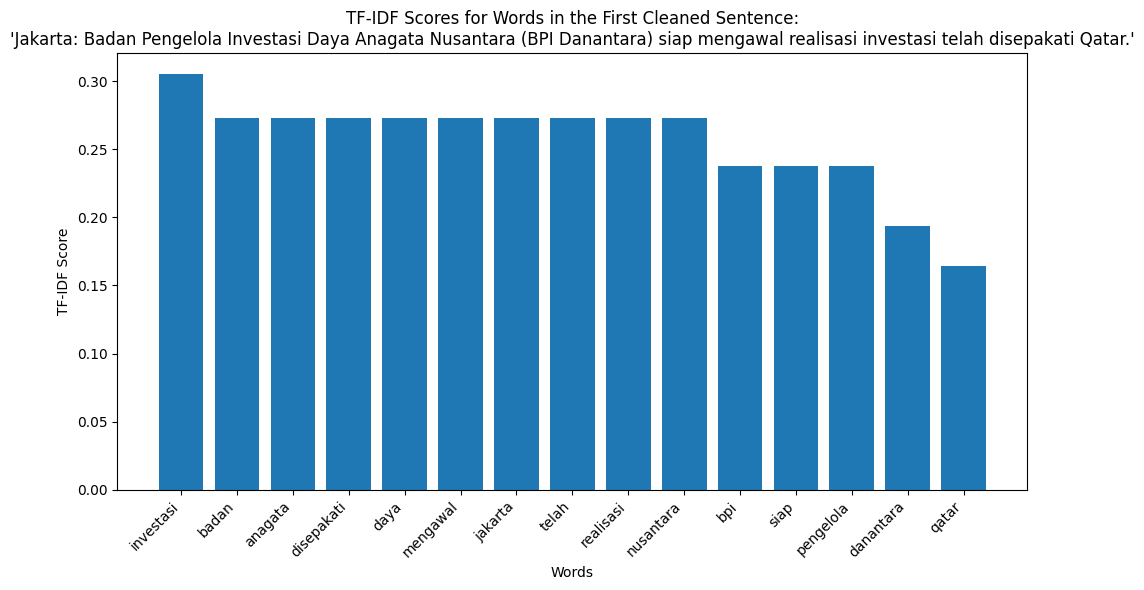

In [9]:
# Get TF-IDF scores for the first sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualize the TF-IDF scores as a histogram
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

### TF-IDF Score for 'investasi' in Each Sentence


TF-IDF Scores for 'investasi' in each sentence::


,Sentence Number,TF-IDF Score (investasi)
0,1,0.305311
1,2,0.000000
2,3,0.139279
3,4,0.168338
4,5,0.000000
5,6,0.000000
6,7,0.000000
7,8,0.000000
8,9,0.205448
9,10,0.167613


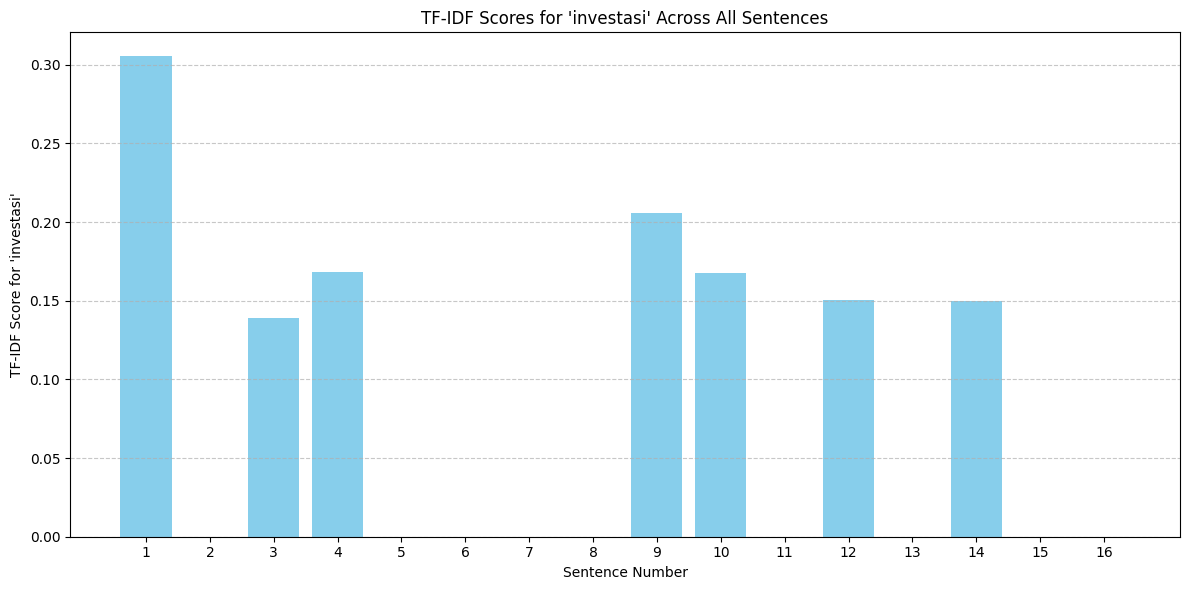

In [10]:
investasi_index = list(feature_names).index('investasi')
investasi_tfidf_scores = []
for i, _ in enumerate(sentence):
    score = features[i, investasi_index] # Get TF-IDF score for 'investasi' in sentence i
    investasi_tfidf_scores.append(score)

investasi_df = pd.DataFrame({
    'Sentence Number': range(1, len(sentence) + 1),
    'TF-IDF Score (investasi)': investasi_tfidf_scores
})
print("\nTF-IDF Scores for 'investasi' in each sentence::")
display(investasi_df)

# Visualize the TF-IDF scores for 'investasi' in each sentence
plt.figure(figsize=(12, 6))
plt.bar(investasi_df['Sentence Number'], investasi_df['TF-IDF Score (investasi)'], color='skyblue')
plt.xlabel("Sentence Number")
plt.ylabel("TF-IDF Score for 'investasi'")
plt.title("TF-IDF Scores for 'investasi' Across All Sentences")
plt.xticks(range(1, len(sentence) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### TF-IDF Score for Each Sentence

In [11]:
# Variable initialization
sent_index = 0
sent_scores = []

# Calculate average TF-IDF score for each sentence with detailed output
print("\n**Calculating Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print(f"  Sum of TF-IDF scores: {sent_score:.4f}")
    print(f"  Number of words: {sent_length}")
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print(f"  Average TF-IDF score: {avg_score:.4f}")
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print(f"\nThreshold (Average of all Sentence Scores): {threshold:.4f}")


**Calculating Average TF-IDF Score for Each Sentence:**
- Sentence 1
  Sum of TF-IDF scores: 3.8372
  Number of words: 15
  Average TF-IDF score: 0.2558
- Sentence 2
  Sum of TF-IDF scores: 3.2629
  Number of words: 11
  Average TF-IDF score: 0.2966
- Sentence 3
  Sum of TF-IDF scores: 4.1870
  Number of words: 19
  Average TF-IDF score: 0.2204
- Sentence 4
  Sum of TF-IDF scores: 3.6823
  Number of words: 14
  Average TF-IDF score: 0.2630
- Sentence 5
  Sum of TF-IDF scores: 4.0662
  Number of words: 17
  Average TF-IDF score: 0.2392
- Sentence 6
  Sum of TF-IDF scores: 4.9283
  Number of words: 25
  Average TF-IDF score: 0.1971
- Sentence 7
  Sum of TF-IDF scores: 3.1233
  Number of words: 11
  Average TF-IDF score: 0.2839
- Sentence 8
  Sum of TF-IDF scores: 3.4082
  Number of words: 12
  Average TF-IDF score: 0.2840
- Sentence 9
  Sum of TF-IDF scores: 3.9294
  Number of words: 19
  Average TF-IDF score: 0.2068
- Sentence 10
  Sum of TF-IDF scores: 3.6726
  Number of words: 14
  A

# **(6) Average TF-IDF Score Calculation and Visualization**
Here, the average TF-IDF score for each sentence is computed. Sentences with higher average scores are considered more important. A histogram visualizes these scores, and an explanation of the histogram's interpretation is provided.

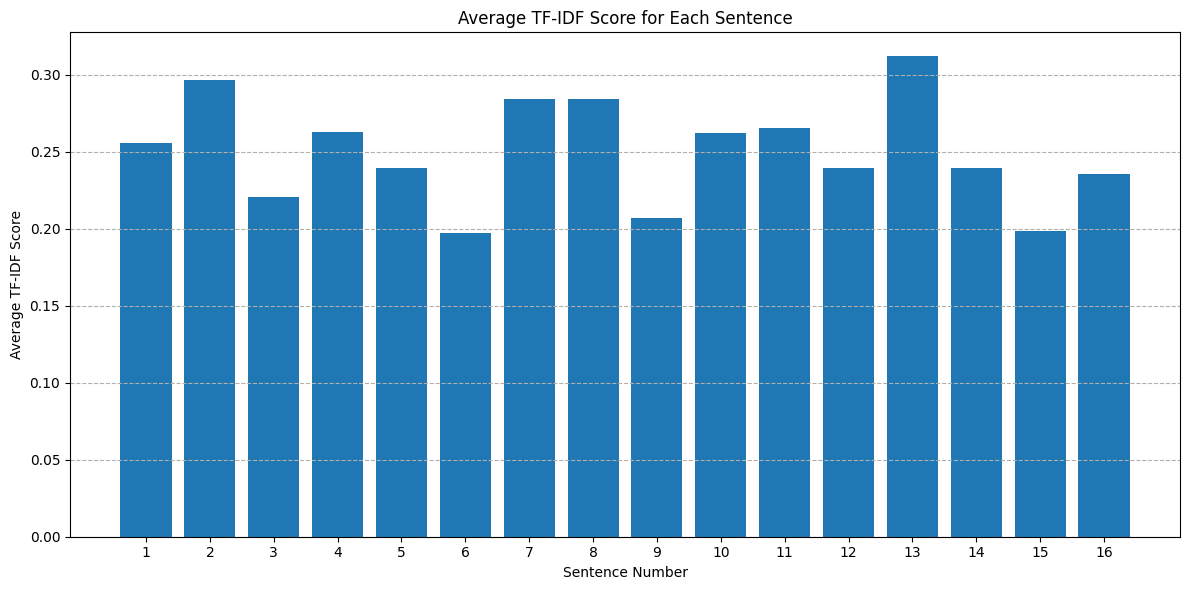


Explanation of the Histogram :
Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.

The histogram above is like a bar chart that shows this score for each sentence:
- The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.
- The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.

 What does the height of the bar tell us?
- Taller bar: A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.
- Shorter bar: A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main 

In [12]:
# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Explanation:
print("\nExplanation of the Histogram :")
print("Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.")
print("\nThe histogram above is like a bar chart that shows this score for each sentence:")
print("- The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.")
print("- The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.")
print("\n What does the height of the bar tell us?")
print("- Taller bar: A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.")
print("- Shorter bar: A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main topic.")
print("\nSo, by looking at this chart, you can quickly get a sense of which sentences in the article are likely to be the most informative based on the words they use.")

# **(7) Generated Summary**
This step filters sentences based on whether their average TF-IDF score meets or exceeds the calculated threshold, compiling them into the final summary of the document.

In [13]:
# Final summary initialization
final_summ = ""

# Get summary sentences
print("\nSummary Sentences (above or equal to the threshold):")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sentence[index]
        print(f"- {sentence[index]}")

print("\nFinal Summary:")
print(final_summ.strip())


Summary Sentences (above or equal to the threshold):
- Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
- Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
- Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
- Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.
- Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.
- "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.
- Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.
- "Kemitraan ini merupakan langkah konkret 